In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler 
from sklearn.metrics import mean_squared_error, mean_absolute_error,  mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import seaborn as sns

In [2]:
folder = r'C:\Users\User\Documents\Bismillah'
tahun_data = [2020, 2021, 2022, 2023, 2024]
list_df = []

for tahun in tahun_data:
    path = os.path.join(folder, f'{tahun} Summary.xlsx')
    df = pd.read_excel(path)
    df['Tahun'] = tahun
    list_df.append(df)

df_all = pd.concat(list_df, ignore_index=True)

In [3]:
print("--- Dataset Info ---")
print(df_all.info(), '\n')

print("--- Missing Values per Column ---")
print(df_all.isnull().sum(), '\n')

print("--- Duplicate Rows ---")
print(df_all.duplicated().sum(), '\n')


if df_all.duplicated().any():
    df_all = df_all.drop_duplicates()
    print("Duplicates dropped, new shape:", df_all.shape)


numeric_cols = df_all.select_dtypes(include=['float64', 'int64'])
print("--- Correlation Matrix ---")
print(numeric_cols.corr(), '\n')

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319 entries, 0 to 318
Data columns (total 31 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Vendor        318 non-null    object 
 1   Brand         313 non-null    object 
 2   JanQty        310 non-null    float64
 3   JanNet Sales  310 non-null    float64
 4   FebQty        310 non-null    float64
 5   FebNet Sales  310 non-null    object 
 6   MarQty        312 non-null    float64
 7   MarNet Sales  312 non-null    object 
 8   AprQty        308 non-null    float64
 9   AprNet Sales  308 non-null    object 
 10  JunQty        311 non-null    float64
 11  JunNet Sales  311 non-null    object 
 12  JulQty        310 non-null    float64
 13  JulNet Sales  310 non-null    object 
 14  AgtQty        308 non-null    float64
 15  AgtNet Sales  307 non-null    object 
 16  SepQty        308 non-null    float64
 17  SepNet Sales  307 non-null    object 
 18  OktQty   

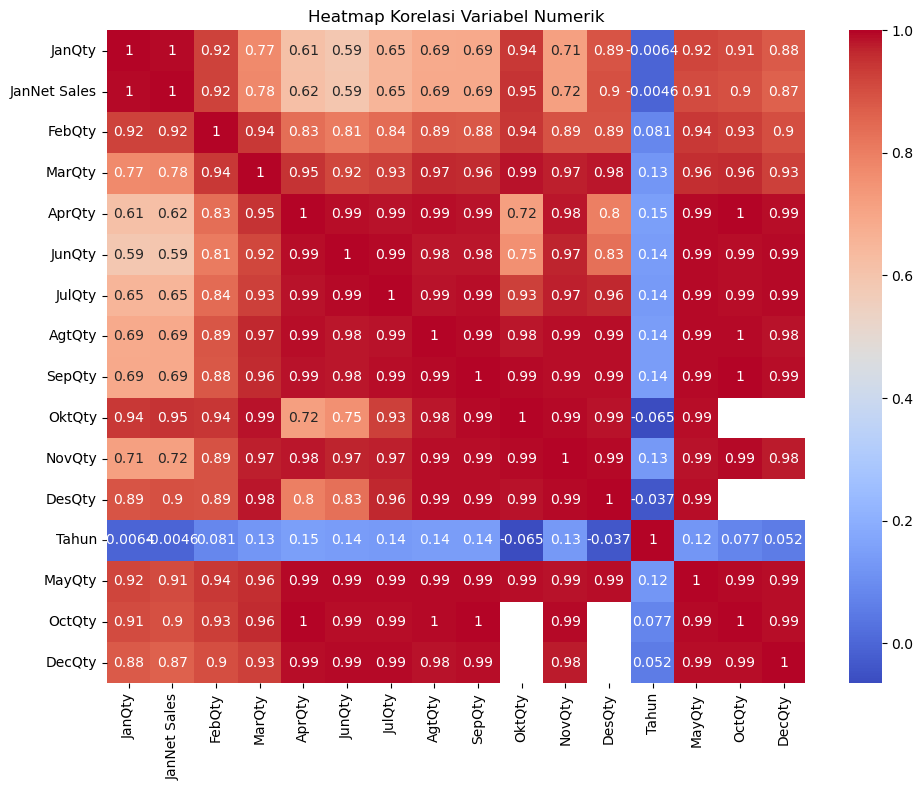

In [4]:
plt.figure(figsize=(10,8))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title("Heatmap Korelasi Variabel Numerik")
plt.tight_layout()
plt.show()

In [5]:
bulan_nama = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Agt','Sep','Okt','Nov','Des']
records = []
for _, row in df_all.iterrows():
    for i, b in enumerate(bulan_nama, start=1):
        # Cek variasi nama kolom dengan atau tanpa spasi
        col1 = f'{b}Net Sales'
        col2 = f'{b} Net Sales'
        if col1 in df_all.columns:
            col = col1
        elif col2 in df_all.columns:
            col = col2
        else:
            col = None
        
        if col is not None:
            val = row.get(col, np.nan)
            if pd.notna(val):
                try:
                    clean_val = float(str(val).replace(',','').strip())
                    records.append({'Tahun': row['Tahun'], 'Bulan': i, 'Penjualan_Bersih': clean_val})
                except:
                    pass

df_ts = pd.DataFrame(records)
df_ts['Tanggal'] = pd.to_datetime(df_ts['Tahun'].astype(str) + '-' + df_ts['Bulan'].astype(str) + '-01')

df_monthly = df_ts.groupby('Tanggal')['Penjualan_Bersih'].sum().reset_index()

print("Missing in time series:", df_monthly.isnull().sum(), '\n')
print("Duplicates in TS:", df_monthly.duplicated().sum(), '\n')
print(df_monthly[['Tanggal', 'Penjualan_Bersih']].head(10))  # tampilkan 10 baris pertama


df_monthly['Bulan'] = df_monthly['Tanggal'].dt.month
df_monthly['Lag_1'] = df_monthly['Penjualan_Bersih'].shift(1)
df_monthly = df_monthly.dropna().reset_index(drop=True)

Missing in time series: Tanggal             0
Penjualan_Bersih    0
dtype: int64 

Duplicates in TS: 0 

     Tanggal  Penjualan_Bersih
0 2020-01-01      2.485500e+10
1 2020-02-01      1.048432e+10
2 2020-03-01      5.920911e+09
3 2020-04-01      1.650581e+09
4 2020-06-01      1.547015e+09
5 2020-07-01      2.851217e+09
6 2020-08-01      3.987961e+09
7 2020-09-01      4.440590e+09
8 2020-10-01      4.572613e+09
9 2020-11-01      5.247716e+09


In [6]:
# Urutkan data berdasarkan tanggal
df_monthly_sorted = df_monthly.sort_values('Tanggal').reset_index(drop=True)

# Hitung indeks pembagi untuk 60:40
train_size_60 = int(len(df_monthly_sorted) * 0.6)
train_60 = df_monthly_sorted.iloc[:train_size_60]
test_40 = df_monthly_sorted.iloc[train_size_60:]

print("Pembagian 60:40 berdasarkan urutan waktu:")
print("Jumlah data train:", len(train_60))
print("Jumlah data test :", len(test_40))


Pembagian 60:40 berdasarkan urutan waktu:
Jumlah data train: 31
Jumlah data test : 21


In [7]:
# Cek missing dan duplikasi
print("Missing in time series:", df_monthly.isnull().sum(), '\n')
print("Duplicates in TS:", df_monthly.duplicated().sum(), '\n')

# Buat fitur tambahan
df_monthly['Bulan'] = df_monthly['Tanggal'].dt.month
df_monthly['Lag_1'] = df_monthly['Penjualan_Bersih'].shift(1)
df_monthly = df_monthly.dropna().reset_index(drop=True)

# Tentukan fitur yang akan digunakan
features = ['Penjualan_Bersih', 'Bulan', 'Lag_1']

# Urutkan berdasarkan tanggal
df_monthly_sorted = df_monthly.sort_values('Tanggal').reset_index(drop=True)

# Bagi data 60:40 berdasarkan baris
split_index = int(len(df_monthly_sorted) * 0.6)
train_df = df_monthly_sorted.iloc[:split_index]
val_df   = df_monthly_sorted.iloc[split_index:]

# Scaling menggunakan MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(train_df[features])  # Fit hanya pada data latih (60%)

train_60_scaled = scaler.transform(train_df[features])
test_40_scaled  = scaler.transform(val_df[features])

print("Preprocessing 60:40 selesai:")
print("Train shape:", train_60_scaled.shape)
print("Val shape  :", test_40_scaled.shape)


Missing in time series: Tanggal             0
Penjualan_Bersih    0
Bulan               0
Lag_1               0
dtype: int64 

Duplicates in TS: 0 

Preprocessing 60:40 selesai:
Train shape: (30, 3)
Val shape  : (21, 3)


In [8]:
def create_dataset(dataset, time_steps=12):
    X, y = [], []
    for i in range(len(dataset) - time_steps):
        X.append(dataset[i:i + time_steps, :])
        y.append(dataset[i + time_steps, 0])
    return np.array(X), np.array(y)

# Parameter time steps
time_steps = 12

In [9]:
# Gunakan data hasil scaling dari pembagian 60:40
X_train_60, y_train_60 = create_dataset(train_60_scaled, time_steps)
X_test_40, y_test_40 = create_dataset(test_40_scaled, time_steps)

print("X_train_60 shape:", X_train_60.shape)
print("X_test_40 shape :", X_test_40.shape)

# Reshape jika hanya 2 dimensi (untuk LSTM butuh 3 dimensi)
if len(X_train_60.shape) == 2:
    X_train_60 = X_train_60.reshape((X_train_60.shape[0], X_train_60.shape[1], 1))
if len(X_test_40.shape) == 2:
    X_test_40 = X_test_40.reshape((X_test_40.shape[0], X_test_40.shape[1], 1))

# --- Fungsi membuat sequence sliding window (opsional) ---
def create_sequences(data, window=6):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window, 1:])  # semua fitur kecuali target
        y.append(data[i + window, 0])   # target tetap Penjualan_Bersih
    return np.array(X), np.array(y)
# Buat sequence training dan validasi dari data 60:40
X_train_60, y_train_60 = create_sequences(train_60_scaled, window=6)

# Untuk validasi: gabungkan 6 baris terakhir dari train_60 + seluruh test_40
X_val_60, y_val_60 = create_sequences(np.vstack([train_60_scaled[-6:], test_40_scaled]), window=6)
# Buat sequence untuk train dan val (berdasarkan 60:40)
X_train_seq, y_train_seq = create_sequences(train_60_scaled, window=6)

# Untuk validasi: ambil 6 data terakhir dari train + test_40
X_val_seq, y_val_seq = create_sequences(np.vstack([train_60_scaled[-6:], test_40_scaled]), window=6)

print("X_train_seq shape:", X_train_seq.shape)
print("y_train_seq shape:", y_train_seq.shape)
print("X_val_seq shape  :", X_val_seq.shape)
print("y_val_seq shape  :", y_val_seq.shape)

# Input shape untuk LSTM
input_shape_60 = (X_train_seq.shape[1], X_train_seq.shape[2])
print("Input shape untuk LSTM (60:40):", input_shape_60)


X_train_60 shape: (18, 12, 3)
X_test_40 shape : (9, 12, 3)
X_train_seq shape: (24, 6, 2)
y_train_seq shape: (24,)
X_val_seq shape  : (21, 6, 2)
y_val_seq shape  : (21,)
Input shape untuk LSTM (60:40): (6, 2)


In [10]:
# Bangun model stacked LSTM untuk data 80:20
model = Sequential([
    Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 6, 64)               │          17,152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 6, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,601 (115.63 KB)

 Trainable params: 29,601 (115.63 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Gunakan early stopping untuk mencegah overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train_seq, y_train_seq,
    epochs=100,
    batch_size=16,
    validation_data=(X_val_seq, y_val_seq),
    callbacks=[early_stop],
    verbose=1
)
# Catat performa akhir
val_loss = history.history['val_loss'][-1]
print(f"Final Validation Loss (MSE): {val_loss:.4f}")

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 326ms/step - loss: 0.3375 - mae: 0.5181 - val_loss: 7.4222 - val_mae: 2.6502
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.2603 - mae: 0.4388 - val_loss: 6.9715 - val_mae: 2.5652
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.2299 - mae: 0.3937 - val_loss: 6.5363 - val_mae: 2.4801
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.1764 - mae: 0.3387 - val_loss: 6.0882 - val_mae: 2.3893
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.1395 - mae: 0.3138 - val_loss: 5.6149 - val_mae: 2.2895
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.1227 - mae: 0.2915 - val_loss: 5.1189 - val_mae: 2.1801
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.1038 - mae: 0.2623 - val_loss: 4.6487 - val_mae: 2.0711
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0923 - mae: 0.2577 - val_loss: 4.2679 - val_mae: 1.9787
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0968 - mae:

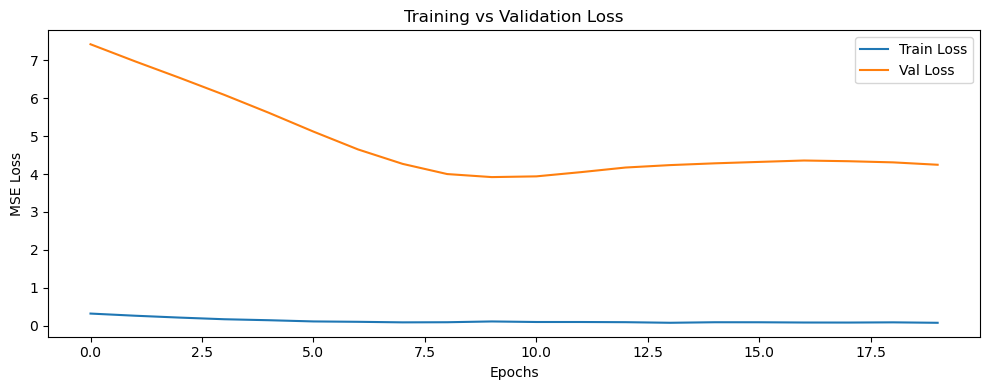

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()


In [13]:
# === Prediksi pada data validasi (60:40) ===
y_pred_40 = model.predict(X_val_seq)

# Buat dummy array agar bisa inverse_transform (jumlah kolom = jumlah fitur saat scaling)
dummy_val_60 = np.zeros((len(y_val_seq), train_60_scaled.shape[1]))
dummy_pred_60 = np.zeros((len(y_pred_40), train_60_scaled.shape[1]))

# Isi kolom target (kolom ke-0)
dummy_val_60[:, 0] = y_val_seq
dummy_pred_60[:, 0] = y_pred_40.flatten()

# Inverse transform ke skala asli
y_val_inv_60 = scaler.inverse_transform(dummy_val_60)[:, 0]
y_pred_inv_60 = scaler.inverse_transform(dummy_pred_60)[:, 0]

# Cetak contoh hasil
print("=== Contoh Hasil Inverse Transform (60:40) ===")
for i in range(5):
    print(f"Aktual: {y_val_inv_60[i]:.2f}, Prediksi: {y_pred_inv_60[i]:.2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
=== Contoh Hasil Inverse Transform (60:40) ===
Aktual: 6052136933.85, Prediksi: 4728370416.94
Aktual: 9221159104.94, Prediksi: 5164402767.34
Aktual: 10945321060.10, Prediksi: 5314694895.32
Aktual: 18831823763.04, Prediksi: 5320391316.82
Aktual: 17099092972.56, Prediksi: 5203039365.30


In [14]:
# Hitung MSE
mse_60_40 = mean_squared_error(y_val_inv_60, y_pred_inv_60)

# Hitung MAE
mae_60_40 = mean_absolute_error(y_val_inv_60, y_pred_inv_60)

# Hitung MAPE
mape_60_40 = mean_absolute_percentage_error(y_val_inv_60, y_pred_inv_60) * 100  # dalam persen

# Tampilkan hasil
print("Evaluasi Model (60:40) dalam Skala Asli:")
print(f"Mean Squared Error (MSE)     : {mse_60_40:.2f}")
print(f"Mean Absolute Error (MAE)    : {mae_60_40:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape_60_40:.2f}%")


Evaluasi Model (60:40) dalam Skala Asli:
Mean Squared Error (MSE)     : 125597090084896112640.00
Mean Absolute Error (MAE)    : 10706669074.98
Mean Absolute Percentage Error (MAPE): 63.06%


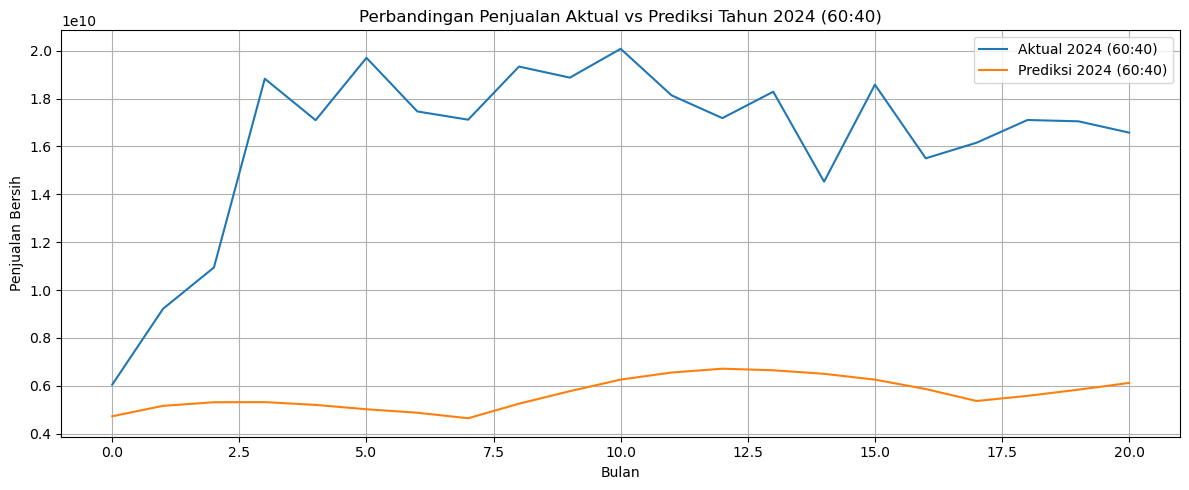

In [15]:
plt.figure(figsize=(12, 5))
plt.plot(y_val_inv_60, label='Aktual 2024 (60:40)')
plt.plot(y_pred_inv_60, label='Prediksi 2024 (60:40)')
plt.title('Perbandingan Penjualan Aktual vs Prediksi Tahun 2024 (60:40)')
plt.xlabel('Bulan')
plt.ylabel('Penjualan Bersih')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [16]:
def mse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


In [18]:
# === Evaluasi Model Validasi (60:40) ===
mse_val_60 = mse(y_val_inv_60, y_pred_inv_60)
rmse_val_60 = rmse(y_val_inv_60,  y_pred_inv_60)
mape_val_60 = mape(y_val_inv_60,  y_pred_inv_60)

print("\n=== METRIK EVALUASI DATA VALIDASI (60:40) ===")
print(f"MSE  : {mse_val_60:.2f}")
print(f"RMSE : {rmse_val_60:.2f}")
print(f"MAPE : {mape_val_60:.2f}%")



=== METRIK EVALUASI DATA VALIDASI (60:40) ===
MSE  : 125597090084896112640.00
RMSE : 11207010755.99
MAPE : 63.06%


In [19]:
# Fungsi untuk mengembalikan skala asli dari prediksi
def inv_transform_60(y_preds, X_prev):
    if X_prev.ndim == 3:
        last_feats = X_prev[:, -1, :]
    else:
        last_feats = X_prev
    arr = np.hstack([y_preds.reshape(-1, 1), last_feats])
    return scaler.inverse_transform(arr)[:, 0]
# Buat fitur window dari data validasi
X_val_full_60 = np.vstack([train_60_scaled[-6:], test_40_scaled])
X_val_window_feats_60 = np.array([
    X_val_full_60[i + 6 - 1, 1:]
    for i in range(len(test_40_scaled))
])

# Prediksi menggunakan model
desired_steps = 3
batch_size_pred = max(1, len(X_val_seq) // desired_steps)
preds_val_60 = model.predict(X_val_seq, batch_size=batch_size_pred, verbose=1)

# Kembalikan ke skala asli
y_val_actual_60 = inv_transform_60(y_val_seq, X_val_window_feats_60)
y_val_pred_60   = inv_transform_60(preds_val_60.flatten(), X_val_window_feats_60)

# Cetak hasil prediksi vs aktual
print("=== Hasil Prediksi Validasi 60:40 ===")
for i in range(len(y_val_actual_60)):
    print(f"Bulan ke-{i+1}: Aktual = {y_val_actual_60[i]:.2f}, Prediksi = {y_val_pred_60[i]:.2f}")
# Siapkan window terakhir dari data training + testing (full)
data_60_scaled_full = np.vstack([train_60_scaled, test_40_scaled])
last_window_60 = data_60_scaled_full[-6:, 1:]  # fitur 'Bulan' dan 'Lag_1'

future_preds_60 = []

for i in range(12):
    X_input = last_window_60.reshape(1, 6, 2)
    y_pred_scaled = model.predict(X_input)

    y_pred_actual = inv_transform_60(y_pred_scaled.flatten(), last_window_60[-1, :].reshape(1, -1))[0]
    future_preds_60.append(y_pred_actual)

    # Update window
    next_month = ((last_window_60[-1, 0] % 12) + 1)
    next_input = np.array([[next_month, y_pred_scaled[0][0]]])
    last_window_60 = np.vstack([last_window_60[1:], next_input])


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step  
=== Hasil Prediksi Validasi 60:40 ===
Bulan ke-1: Aktual = 6052136933.85, Prediksi = 4728370416.94
Bulan ke-2: Aktual = 9221159104.94, Prediksi = 5164402767.34
Bulan ke-3: Aktual = 10945321060.10, Prediksi = 5314694895.32
Bulan ke-4: Aktual = 18831823763.04, Prediksi = 5320391316.82
Bulan ke-5: Aktual = 17099092972.56, Prediksi = 5203039365.30
Bulan ke-6: Aktual = 19705331640.14, Prediksi = 5021883916.33
Bulan ke-7: Aktual = 17464193698.92, Prediksi = 4876725046.27
Bulan ke-8: Aktual = 17120514882.00, Prediksi = 4645792550.83
Bulan ke-9: Aktual = 19340284500.00, Prediksi = 5253703841.50
Bulan ke-10: Aktual = 18876877977.14, Prediksi = 5777002251.37
Bulan ke-11: Aktual = 20081568328.66, Prediksi = 6261328999.51
Bulan ke-12: Aktual = 18137389202.88, Prediksi = 6556046433.98
Bulan ke-13: Aktual = 17185132762.68, Prediksi = 6716686397.41
Bulan ke-14: Aktual = 18289071590.86, Prediksi = 6650471655.56
Bulan ke-15: Aktual = 14530070820.88, Prediksi = 650

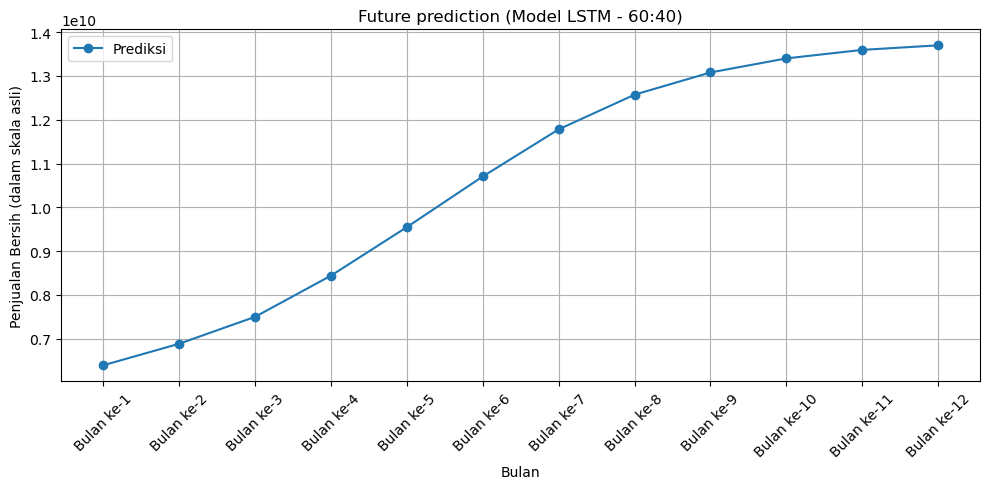

In [21]:
bulan_labels = [f"Bulan ke-{i}" for i in range(1, 13)]

plt.figure(figsize=(10, 5))
plt.plot(future_preds_60, marker='o', linestyle='-', label='Prediksi')
plt.xticks(ticks=range(12), labels=bulan_labels, rotation=45)
plt.title("Future prediction (Model LSTM - 60:40)")
plt.xlabel("Bulan")
plt.ylabel("Penjualan Bersih (dalam skala asli)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
